# 04 · SHAP Explainability & Retention Recommendations

Open up the XGBoost model with SHAP: which features drive churn globally, why a
single customer is flagged, and what to *do* about it.

In [1]:
%matplotlib inline
import shap
from churn import data, explain, features, model

df = features.engineer(data.load_clean())
X_train, X_test, y_train, y_test = model.make_split(df)
xgb = model.build_models()["XGBoost"]
xgb.fit(X_train, y_train)
explanation = explain.shap_explanation(xgb, X_test)
explanation.values.shape

(1409, 48)

## Global feature importance
Contract type dominates; tenure is the clear second driver.

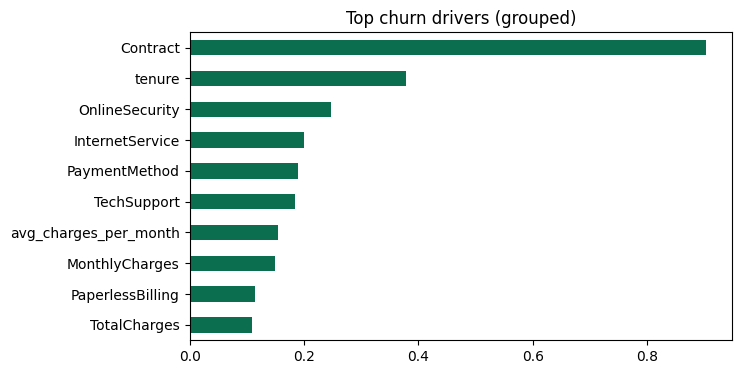

In [2]:
grouped = explain.grouped_importance(explanation).head(10)
grouped.sort_values().plot.barh(color="#0b6e4f", figsize=(7, 4),
                                title="Top churn drivers (grouped)");

## SHAP summary (beeswarm)
Red = high feature value. Month-to-month and low tenure push towards churn.

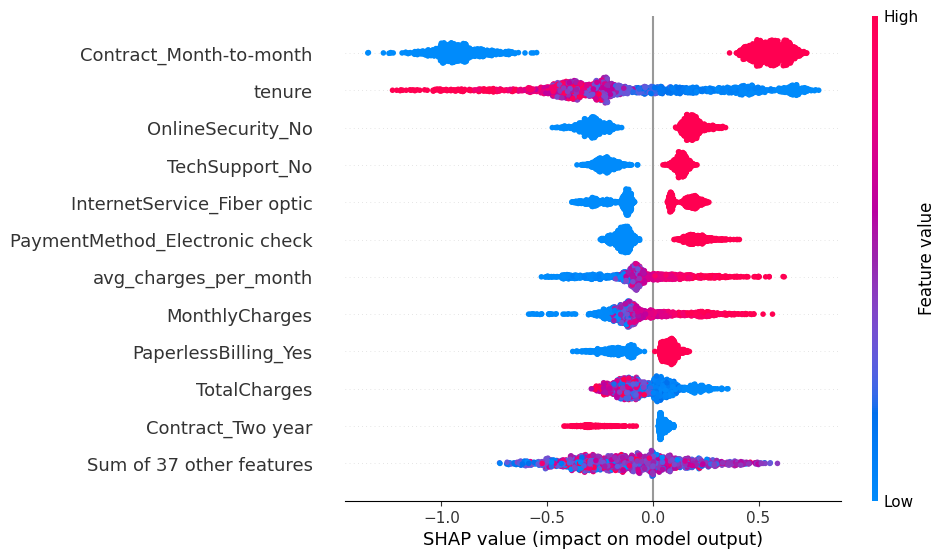

In [3]:
shap.plots.beeswarm(explanation, max_display=12);

## Explaining a single high-risk customer

customer #3380 - churn probability 95.9%


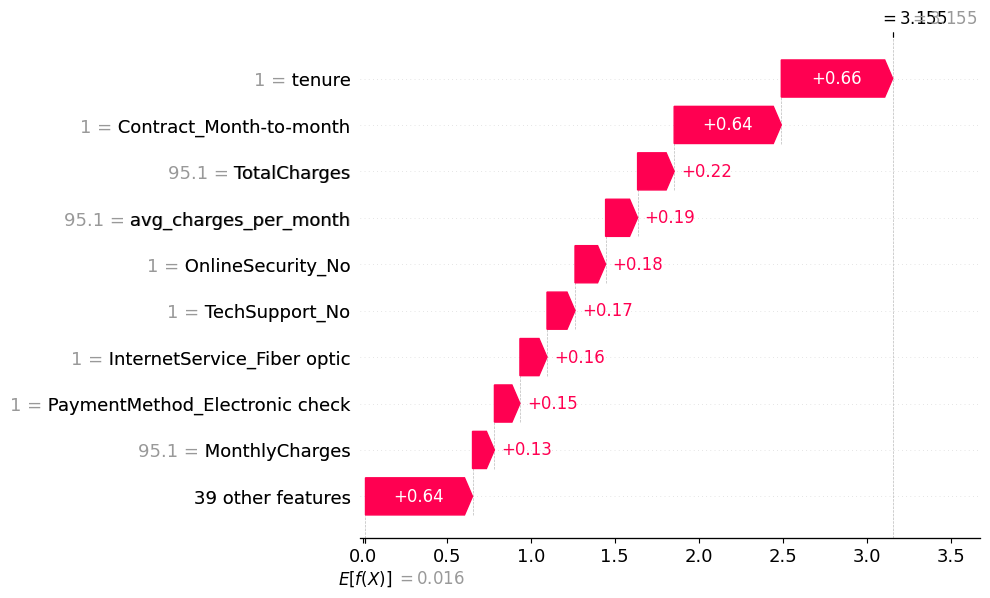

In [4]:
proba = xgb.predict_proba(X_test)[:, 1]
i = int(proba.argmax())
print(f"customer #{X_test.index[i]} - churn probability {proba[i]:.1%}")
shap.plots.waterfall(explanation[i], max_display=10);

## How churn risk varies with tenure

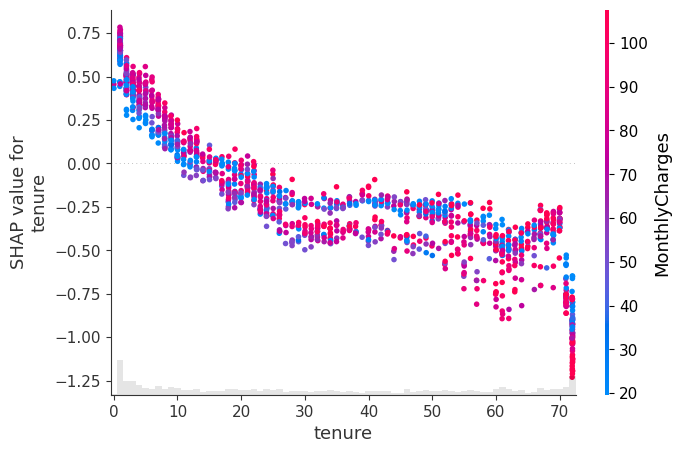

In [5]:
shap.plots.scatter(explanation[:, "tenure"], color=explanation[:, "MonthlyCharges"]);

## Findings

- **Contract type** and **tenure** are the dominant features by a wide margin.
- **Electronic-check** payment and the **absence of online security / tech
  support** materially raise churn risk.
- High **monthly charges** on short tenure flag price-sensitive newcomers.

## Retention recommendations

1. **Convert month-to-month customers to annual contracts** with targeted
   discounts - the single biggest lever.
2. **Invest in the first 12 months**: onboarding, proactive support and loyalty
   perks for new customers.
3. **Bundle tech support / online security** to raise switching costs.
4. **Move electronic-check payers to auto-pay** to reduce passive churn.

> Educational demo on a public dataset - validate before acting on any single
> prediction.